# VELOCE III: Reconstructing Radial Velocity Curves of Classical Cepheids

Giordano Viviani and Richard I. Anderson (2025)

email: giordano.viviani@proton.me

This notebook reproduce step-by-step the analysis conducted to create the framework published in *Viviani et Anderson 2025* (doi: 10.48550/arXiv.2511.10534)

In [1]:
%matplotlib inline

import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as sp
from astropy.io import votable
from matplotlib import rc
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Import the veloce framework library
import velocefw as vf

rc("text", usetex=True)
rc("text.latex", preamble=r"\usepackage{amsmath}")
rc("font", family="serif")

logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)

# Okabe and Ito colorscheme
color_safe = {
    "black": "#000000",
    "light_green": "#009E73",
    "blue": "#0072B2",
    "light_blue": "#56B4E9",
    "yellow": "#F0E442",
    "orange": "#E69F00",
    "dark_orange": "#D55E00",
    "pink": "#CC79A7",
}

# Label and font sizes for plots
label_size = 11

# Set random seed for reproducibility
rng = np.random.default_rng(42)

## Prepare Data
### VELOCE DR1 data
Accessing the VELOCE DR1 (Anderson, Viviani et al, 2024) data.

The code makes use of the environment variable DATASETS, and it assumes the VELOCE DR1 fits files are in a sub-folder.
Please change the path to where you saved the VELOCE DR1 fits files. 

In [2]:
datasets_dir = Path(os.environ.get("DATASETS", "")).expanduser()
veloce_data_dir = datasets_dir / "veloce_dr1_zenodo"

Reading all the headers into a pandas.DataFrame

In [3]:
# Entries not needed for the analysis
entries_to_remove = ["SIMPLE", "BITPIX", "NAXIS", "EXTEND"]

header_list = []
for f in veloce_data_dir.iterdir():
    if f.suffix.lower() == ".fits":
        header = vf.get_header(f)
        for entry in entries_to_remove:
            header.pop(entry, None)
        header_list.append(header)

veloce_headers = pd.DataFrame(header_list).sort_values("NAME").reset_index(drop=True)

Selecting only Classical Cepheids that have been modeled

In [4]:
veloce_headers = veloce_headers[veloce_headers["BOOL_FIT_AVAILABLE"]]
veloce_headers = veloce_headers.reset_index(drop=True)

#### Observations
Get the actual observations for all the targets in with available model.

In [ ]:
read_columns = ["BJD", "RV", "RV_ERR", "MASK"]
veloce_data = pd.DataFrame()
for name in veloce_headers["NAME"]:
    file = veloce_data_dir / f"{name.replace(' ', '_')}.fits"
    temp = vf.get_table(file, 1, columns=read_columns)
    temp["NAME"] = name
    veloce_data = pd.concat([veloce_data, temp], ignore_index=True)

#### Models
Get the published VELOCE coefficients of the radial velocity curves 

In [6]:
read_columns = ["COEFF"]
veloce_fit = pd.DataFrame()
for _, header in veloce_headers.iterrows():
    name = header["NAME"]
    nharm = int(header["N_TERMS_FS"])
    # Slices for the coefficients in the order: constant, fs, poly
    constant_idx = 0
    fs_idx = slice(1, 2 * nharm + 1)
    poly_idx = slice(2 * nharm + 1, None)
    # Read the coefficients from the FITS file
    file = veloce_data_dir / f"{name.replace(' ', '_')}.fits"
    temp_coeff = vf.get_table(file, 2, columns=read_columns)["COEFF"].to_numpy()
    # Extract the coefficients for each component
    v_gamma = temp_coeff[constant_idx]
    fs_coeffs = temp_coeff[fs_idx]
    poly_coeffs = temp_coeff[poly_idx] if header["BOOL_POLYNOMIAL"] else None

    # Store the coefficients in a DataFrame
    temp = pd.DataFrame(
        {
            "NAME": name,
            "V_GAMMA": [v_gamma],
            "FS_COEFFS": [fs_coeffs],
            "POLY_COEFFS": [poly_coeffs],
        },
    )
    veloce_fit = pd.concat([veloce_fit, temp], ignore_index=True)

### Gaia DR3 data 
We want to retrieve epochs from Gaia DR3 vari_cepheids table.

In [7]:
gaiadr3_data_dir = datasets_dir / "gaia_dr3"

votable_file_gaiadr3 = gaiadr3_data_dir / "VOTableFiles" / "gaiadr3.vari_cepheids.vot"
df_gaiadr3 = (
    votable.parse(votable_file_gaiadr3).get_first_table().to_table().to_pandas()
)

From the entire list we select only the targets within VELOCE (remember alf UMi is not present in Gaia DR3)

In [8]:
df_gaiadr3_selection = df_gaiadr3[
    df_gaiadr3["source_id"].isin(veloce_headers["GAIA_DR3_SOURCE_ID"].astype(int))
]
del df_gaiadr3

In [9]:
for col in df_gaiadr3_selection.columns:
    print(col)

solution_id
source_id
pf
pf_error
p1_o
p1_o_error
epoch_g
epoch_g_error
epoch_bp
epoch_bp_error
epoch_rp
epoch_rp_error
epoch_rv
epoch_rv_error
int_average_g
int_average_g_error
int_average_bp
int_average_bp_error
int_average_rp
int_average_rp_error
average_rv
average_rv_error
peak_to_peak_g
peak_to_peak_g_error
peak_to_peak_bp
peak_to_peak_bp_error
peak_to_peak_rp
peak_to_peak_rp_error
peak_to_peak_rv
peak_to_peak_rv_error
metallicity
metallicity_error
r21_g
r21_g_error
r31_g
r31_g_error
phi21_g
phi21_g_error
phi31_g
phi31_g_error
num_clean_epochs_g
num_clean_epochs_bp
num_clean_epochs_rp
num_clean_epochs_rv
zp_mag_g
zp_mag_bp
zp_mag_rp
num_harmonics_for_p1_g
num_harmonics_for_p1_bp
num_harmonics_for_p1_rp
num_harmonics_for_p1_rv
reference_time_g
reference_time_bp
reference_time_rp
reference_time_rv
fund_freq1
fund_freq1_error
fund_freq2
fund_freq2_error
fund_freq1_harmonic_ampl_g
fund_freq1_harmonic_ampl_g_error
fund_freq1_harmonic_phase_g
fund_freq1_harmonic_phase_g_error
fund_freq1

Check which targets are missing and then calculate the difference in epoch and period between the photometric Gaia data and VELOCE

In [37]:
epoch_offset_gaiadr3 = 2455197.5
epoch_offset_veloce = 2400000.0

gaia_veloce_delta_epoch_list = []
for _, header in veloce_headers.iterrows():
    source_id = int(header["GAIA_DR3_SOURCE_ID"])
    if source_id not in df_gaiadr3_selection["source_id"].to_numpy():
        msg = f"{header['NAME']} (id: {source_id}) is missing in vari_cepheids."
        logger.info(msg)
        print(msg)  # noqa: T201
        continue
    gaia_data = df_gaiadr3_selection[df_gaiadr3_selection["source_id"] == source_id]
    gaia_period = gaia_data["pf"].to_numpy()[0]
    gaia_epoch_g = gaia_data["epoch_g"].to_numpy()[0] + epoch_offset_gaiadr3
    gaia_epoch_bp = gaia_data["epoch_bp"].to_numpy()[0] + epoch_offset_gaiadr3
    gaia_epoch_rp = gaia_data["epoch_rp"].to_numpy()[0] + epoch_offset_gaiadr3
    gaia_epoch_rv = gaia_data["epoch_rv"].to_numpy()[0] + epoch_offset_gaiadr3

    veloce_epoch = header["E"] + epoch_offset_veloce
    veloce_period = header["P"]

    if np.isnan(gaia_epoch_g):
        msg = f"{header['NAME']} (id: {source_id}) has NaN epoch in vari_cepheids."
        logger.info(msg)
        print(msg)  # noqa: T201
        continue

    if np.isnan(gaia_period):
        msg = f"{header['NAME']} (id: {source_id}) has NaN period in vari_cepheids."
        logger.info(msg)
        print(msg)  # noqa: T201
        continue

    while gaia_epoch_g < veloce_epoch:
        gaia_epoch_g += gaia_period
    while gaia_epoch_bp < veloce_epoch:
        gaia_epoch_bp += gaia_period
    while gaia_epoch_rp < veloce_epoch:
        gaia_epoch_rp += gaia_period
    while gaia_epoch_rv < veloce_epoch:
        gaia_epoch_rv += gaia_period

    delta_phase = (gaia_epoch_g - veloce_epoch) / veloce_period % 1
    delta_phase_bp = (gaia_epoch_bp - veloce_epoch) / veloce_period % 1
    delta_phase_rp = (gaia_epoch_rp - veloce_epoch) / veloce_period % 1
    delta_phase_rv = (gaia_epoch_rv - veloce_epoch) / veloce_period % 1

    delta_period = veloce_period - gaia_period

    n_cycles = np.abs(gaia_epoch_g - veloce_epoch) / veloce_period
    phase_lost = (n_cycles * delta_period) / veloce_period

    gaia_veloce_delta_epoch_list.append(
        {
            "NAME": header["NAME"],
            "P": veloce_period,
            "DELTA_PHASE": delta_phase,
            "DELTA_PHASE_BP": delta_phase_bp,
            "DELTA_PHASE_RP": delta_phase_rp,
            "DELTA_PHASE_RV": delta_phase_rv,
            "DELTA_PERIOD": delta_period,
            "N_CYCLES": n_cycles,
            "PHASE_LOST": phase_lost,
        },
    )

gaia_veloce_delta = pd.DataFrame(gaia_veloce_delta_epoch_list)

AH Vel (id: 5519380081746387328) has NaN period in vari_cepheids.
ASAS J064540+0330.4 (id: 3127416965285738880) has NaN period in vari_cepheids.
ASAS J064553+1003.8 (id: 3350719221309022720) has NaN period in vari_cepheids.
ASAS J084951-4627.2 (id: 5329675052782690944) has NaN period in vari_cepheids.
ASAS J091606-5418.6 (id: 5310680130436798336) has NaN period in vari_cepheids.
ASAS J100814-5856.6 (id: 5258280842214814336) has NaN period in vari_cepheids.
ASAS J101016-5811.2 (id: 5258420858142702208) has NaN period in vari_cepheids.
ASAS J102558-5956.8 (id: 5255209665741407744) has NaN period in vari_cepheids.
ASAS J104300-6131.2 (id: 5254027106636092928) has NaN period in vari_cepheids.
ASAS J155847-5341.8 (id: 5980814424369504256) has NaN period in vari_cepheids.
ASAS J162811-5111.9 (id: 5934398717159140736) has NaN period in vari_cepheids.
ASAS J173848-3304.4 (id: 4054155699611497472) has NaN period in vari_cepheids.
ASAS J174108-2328.5 (id: 4116471792510901248) has NaN period in v

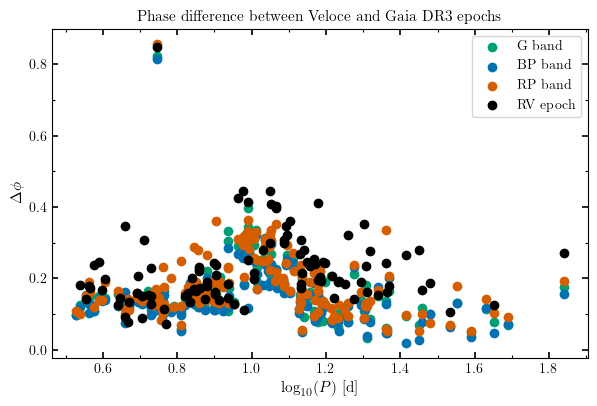

In [38]:
width = 3.46 * 2
height = width / 1.618
fig, axs = plt.subplots(figsize=(width, height))
axs.scatter(
    np.log10(gaia_veloce_delta["P"]),
    gaia_veloce_delta["DELTA_PHASE"],
    color=color_safe["light_green"],
    label="G band",
)
axs.scatter(
    np.log10(gaia_veloce_delta["P"]),
    gaia_veloce_delta["DELTA_PHASE_BP"],
    color=color_safe["blue"],
    label="BP band",
)
axs.scatter(
    np.log10(gaia_veloce_delta["P"]),
    gaia_veloce_delta["DELTA_PHASE_RP"],
    color=color_safe["dark_orange"],
    label="RP band",
)
axs.scatter(
    np.log10(gaia_veloce_delta["P"]),
    gaia_veloce_delta["DELTA_PHASE_RV"],
    color=color_safe["black"],
    label="RV epoch",
)
xlim, ylim = axs.get_xlim(), axs.get_ylim()
x_ticks, x_ticks_minor = np.arange(0.2, 2, 0.2), np.arange(0.2, 2, 0.1)
y_ticks, y_ticks_minor = np.arange(0, 1, 0.2), np.arange(0, 1, 0.1)
vf.plot.format_xticks(axs, x_ticks, x_ticks_minor)
vf.plot.format_yticks(axs, y_ticks, y_ticks_minor)
axs.set_xlim(xlim)
axs.set_ylim(ylim)
axs.set_xlabel(r"$\log_{10}(P)$ [d]", fontsize=label_size)
axs.set_ylabel(r"$\Delta \phi$", fontsize=label_size)
axs.set_title(
    "Phase difference between Veloce and Gaia DR3 epochs",
    fontsize=label_size,
)
axs.legend()


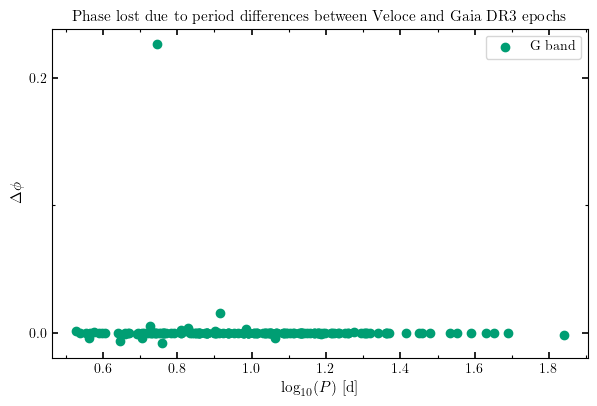

In [39]:
width = 3.46 * 2
height = width / 1.618
fig, axs = plt.subplots(figsize=(width, height))
axs.scatter(
    np.log10(gaia_veloce_delta["P"]),
    gaia_veloce_delta["PHASE_LOST"],
    color=color_safe["light_green"],
    label="G band",
)
xlim, ylim = axs.get_xlim(), axs.get_ylim()
x_ticks, x_ticks_minor = np.arange(0.2, 2, 0.2), np.arange(0.2, 2, 0.1)
y_ticks, y_ticks_minor = np.arange(0, 1, 0.2), np.arange(0, 1, 0.1)
vf.plot.format_xticks(axs, x_ticks, x_ticks_minor)
vf.plot.format_yticks(axs, y_ticks, y_ticks_minor)
axs.set_xlim(xlim)
axs.set_ylim(ylim)
axs.set_xlabel(r"$\log_{10}(P)$ [d]", fontsize=label_size)
axs.set_ylabel(r"$\Delta \phi$", fontsize=label_size)
axs.set_title(
    "Phase lost due to period differences between Veloce and Gaia DR3 epochs",
    fontsize=label_size,
)
axs.legend()

In [97]:
ss

'5865376148813776640'

17
2456884.6683504805
[2456095.46230543]
0.505932932235182


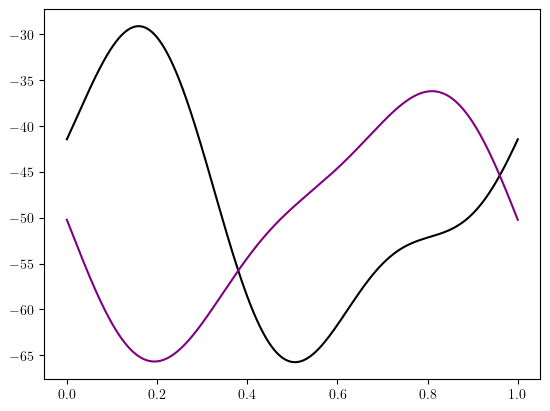

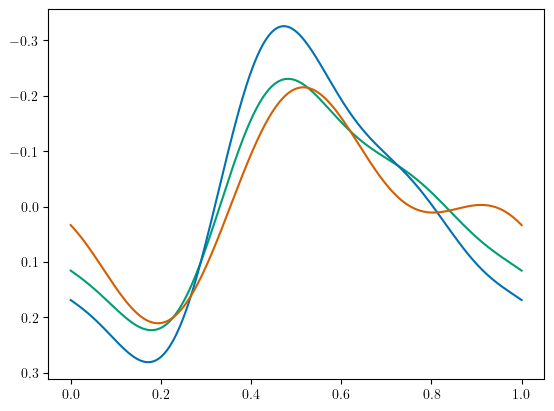

In [ ]:
ss = None
nn = "V1197 Cen"
for _, header in veloce_headers.iterrows():
    if header["NAME"] == nn:
        ss = header["GAIA_DR3_SOURCE_ID"]
E = (
    df_gaiadr3_selection[df_gaiadr3_selection["source_id"] == int(ss)]["epoch_rv"].iloc[
        0
    ]
    + epoch_offset_gaiadr3
)
P = df_gaiadr3_selection[df_gaiadr3_selection["source_id"] == int(ss)]["pf"].iloc[0]
A = df_gaiadr3_selection[df_gaiadr3_selection["source_id"] == int(ss)][
    "fund_freq1_harmonic_ampl_rv"
].iloc[0]
phi = df_gaiadr3_selection[df_gaiadr3_selection["source_id"] == int(ss)][
    "fund_freq1_harmonic_phase_rv"
].iloc[0]
A_g = df_gaiadr3_selection[df_gaiadr3_selection["source_id"] == int(ss)][
    "fund_freq1_harmonic_ampl_g"
].iloc[0]
phi_g = df_gaiadr3_selection[df_gaiadr3_selection["source_id"] == int(ss)][
    "fund_freq1_harmonic_phase_g"
].iloc[0]
A_bp = df_gaiadr3_selection[df_gaiadr3_selection["source_id"] == int(ss)][
    "fund_freq1_harmonic_ampl_bp"
].iloc[0]
phi_bp = df_gaiadr3_selection[df_gaiadr3_selection["source_id"] == int(ss)][
    "fund_freq1_harmonic_phase_bp"
].iloc[0]
A_rp = df_gaiadr3_selection[df_gaiadr3_selection["source_id"] == int(ss)][
    "fund_freq1_harmonic_ampl_rp"
].iloc[0]
phi_rp = df_gaiadr3_selection[df_gaiadr3_selection["source_id"] == int(ss)][
    "fund_freq1_harmonic_phase_rp"
].iloc[0]
vg = df_gaiadr3_selection[df_gaiadr3_selection["source_id"] == int(ss)][
    "average_rv"
].iloc[0]

print(
    df_gaiadr3_selection[df_gaiadr3_selection["source_id"] == int(ss)][
        "num_clean_epochs_rv"
    ].iloc[0]
)
print(E)
f = 1 / P

t_model = np.linspace(0, 1, 1000)
coeffs = veloce_fit[veloce_fit["NAME"] == nn]["FS_COEFFS"].iloc[0]
nharm = int(len(coeffs) / 2 + 0.5)
fs = vf.model.FourierSeries(nharm=nharm)
modelrv = fs.evaluate(coeffs, t_model)
vgamm = veloce_fit[veloce_fit["NAME"] == nn]["V_GAMMA"].iloc[0]
print(
    veloce_headers[veloce_headers["NAME"] == nn]["E"].to_numpy() + epoch_offset_veloce
)
print(
    (
        E
        - (
            df_gaiadr3_selection[df_gaiadr3_selection["source_id"] == int(ss)][
                "reference_time_rv"
            ].iloc[0]
            + epoch_offset_gaiadr3
        )
    )
    / P
    % 1
)


# t_model = np.linspace(min(t), max(t), 1000)
def model_FS(x, A, phi):
    model = np.zeros_like(x)
    for k in range(len(A)):
        model += A[k] * np.cos(2 * np.pi * (k + 1) * t_model + phi[k])
    return model


model_rv = model_FS(t_model, A, phi)

fig, axs = plt.subplots()
# plt.scatter(t, mag, s=5)
plt.plot(t_model, model_rv + vg, color="black")
plt.plot(t_model, modelrv + vgamm, color="purple")

#
model_g = model_FS(t_model, A_g, phi_g)
model_bp = model_FS(t_model, A_bp, phi_bp)
model_rp = model_FS(t_model, A_rp, phi_rp)
fig, axs = plt.subplots()
# plt.scatter(t, mag, s=5)
plt.plot(t_model, model_g, color=color_safe["light_green"])
plt.plot(t_model, model_bp, color=color_safe["blue"])
plt.plot(t_model, model_rp, color=color_safe["dark_orange"])
plt.gca().invert_yaxis()


In [29]:
P

np.float64(5.55485667685776)

In [35]:
142 * (veloce_headers[veloce_headers.NAME == nn].P - P)

177    1.264441
Name: P, dtype: float64

In [36]:
veloce_headers[veloce_headers.NAME == nn].P_ERR

177    0.002581
Name: P_ERR, dtype: float64

In [ ]:
(
    (
        df_gaiadr3_selection[df_gaiadr3_selection["source_id"] == int(ss)][
            "reference_time_rp"
        ].iloc[0]
        - df_gaiadr3_selection[df_gaiadr3_selection["source_id"] == int(ss)][
            "epoch_rp"
        ].iloc[0]
    )
    / df_gaiadr3_selection[df_gaiadr3_selection["source_id"] == int(ss)]["pf"].iloc[0]
) % 1

np.float64(0.483490888652534)

In [ ]:
(
    (
        df_gaiadr3_selection[df_gaiadr3_selection["source_id"] == int(ss)][
            "reference_time_rv"
        ].iloc[0]
        - df_gaiadr3_selection[df_gaiadr3_selection["source_id"] == int(ss)][
            "epoch_rv"
        ].iloc[0]
    )
    / df_gaiadr3_selection[df_gaiadr3_selection["source_id"] == int(ss)]["pf"].iloc[0]
) % 1

np.float64(0.49406706774860876)

In [ ]:
(
    (
        df_gaiadr3_selection[df_gaiadr3_selection["source_id"] == int(ss)][
            "epoch_rv"
        ].iloc[0]
        + epoch_offset_gaiadr3
    )
    - (veloce_headers[veloce_headers.NAME == nn].E.iloc[0] + epoch_offset_veloce)
) / P

np.float64(142.0749608777335)

In [21]:
veloce_headers[veloce_headers.NAME == nn].E.iloc[0] + epoch_offset_veloce

np.float64(2456095.4623054345)

In [ ]:
veloce_fit[veloce_fit["NAME"] == nn]["FS_COEFFS"].to_numpy()

array([array([ -0.64726997, -13.50346362,   0.64726997,  -3.19460695])],
      dtype=object)

In [44]:
int(ss) in df_gaiadr3_selection["source_id"].to_numpy()

True

In [85]:
ss

'5865376148813776640'

In [36]:
df_gaiadr3_selection

,solution_id,source_id,pf,pf_error,p1_o,p1_o_error,epoch_g,epoch_g_error,epoch_bp,epoch_bp_error,...,fund_freq1_harmonic_ampl_rv,fund_freq1_harmonic_ampl_rv_error,fund_freq1_harmonic_phase_rv,fund_freq1_harmonic_phase_rv_error,p2_o,p2_o_error,type_best_classification,type2_best_sub_classification,mode_best_classification,multi_mode_best_classification
120,375316653866487564,2161786374436607616,14.712201,0.002246,NaN,NaN,1734.619016,0.003176,1734.615145,0.002945,...,"[24.639626, 3.915489, --, --, --, --, --, --, ...","[0.14981405, 0.224614, --, --, --, --, --, --,...","[3.7430277, 5.6719675, 0.0, 0.0, 0.0, 0.0, 0.0...","[0.021733586, 0.03325702, --, --, --, --, --, ...",NaN,NaN,DCEP,,FUNDAMENTAL,
232,375316653866487564,5436296928693979392,5.898399,0.000135,NaN,NaN,1755.767341,0.000191,1755.738128,0.000219,...,"[18.282295, 9.106103, 6.2177486, 3.1713283, 2....","[2.3538454, 2.686777, 1.8541527, 1.3817567, 1....","[3.3288999, 5.0818524, 0.806511, 2.7371461, 4....","[0.13610223, 0.19233966, 0.326188, 0.78133446,...",NaN,NaN,DCEP,,FUNDAMENTAL,
244,375316653866487564,6060173364074372352,4.689797,0.000064,NaN,NaN,1686.633813,0.000090,1686.615569,0.000115,...,"[16.774582, 7.48495, 4.3677363, 1.9087173, --,...","[0.8307356, 0.5935003, 0.44479614, 0.49779937,...","[1.5274282, 1.2998211, 0.99620986, 0.526875, 0...","[0.040111262, 0.07318694, 0.10540222, 0.263381...",NaN,NaN,DCEP,,FUNDAMENTAL,
256,375316653866487564,4096107909387492992,5.773427,0.000265,NaN,NaN,1701.558122,0.000374,1701.465905,0.000266,...,NaN,NaN,NaN,NaN,NaN,NaN,DCEP,,FUNDAMENTAL,
297,375316653866487564,2073935223599391872,3.370814,0.000048,NaN,NaN,1757.202631,0.000068,1720.122553,0.000109,...,NaN,NaN,NaN,NaN,NaN,NaN,DCEP,,FUNDAMENTAL,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14857,375316653866487564,5620098679741674496,25.971355,0.003255,NaN,NaN,1726.995659,0.004603,1725.008480,0.017822,...,"[23.89501, 10.133906, 6.41682, 4.54774, --, --...","[21.34672, 26.340816, 24.800903, 25.59147, --,...","[4.0251985, 0.0019137706, 2.1938827, 5.0630407...","[0.82903457, 0.8744768, 1.3907343, 2.417028, -...",NaN,NaN,DCEP,,FUNDAMENTAL,
14879,375316653866487564,1870258975238302208,16.376554,0.005493,NaN,NaN,1728.114875,0.007769,1726.064109,0.001949,...,NaN,NaN,NaN,NaN,NaN,NaN,DCEP,,FUNDAMENTAL,
14940,375316653866487564,4269036830424588800,9.480639,0.001105,NaN,NaN,1698.927304,0.001563,1698.706808,0.001465,...,NaN,NaN,NaN,NaN,NaN,NaN,DCEP,,FUNDAMENTAL,
14969,375316653866487564,2015049435241306368,NaN,NaN,3.620527,0.000075,1686.301332,0.000106,1689.900519,0.000108,...,"[7.569082, 1.5600115, --, --, --, --, --, --, ...","[0.31899288, 0.23068924, --, --, --, --, --, -...","[0.0291192, 5.4391165, 0.0, 0.0, 0.0, 0.0, 0.0...","[0.067182586, 0.3012623, --, --, --, --, --, -...",NaN,NaN,DCEP,,FIRST_OVERTONE,


Remove delta phase outlier

In [ ]:
delta_phase_outlier = gaia_veloce_delta[gaia_veloce_delta["DELTA_PHASE"] > 0.6]  # noqa: PLR2004
print(
    f"Name of outlier: {delta_phase_outlier['NAME'].iloc[0]}, {delta_phase_outlier['source_id'].iloc[0]}"
)  # noqa: T201
# Remove outlier from the DataFrame
gaia_veloce_delta = gaia_veloce_delta[gaia_veloce_delta["DELTA_PHASE"] <= 0.6]  # noqa: PLR2004

KeyError: 'source_id'

Text(0.5, 1.0, 'Phase difference between Veloce and Gaia DR3 epochs')

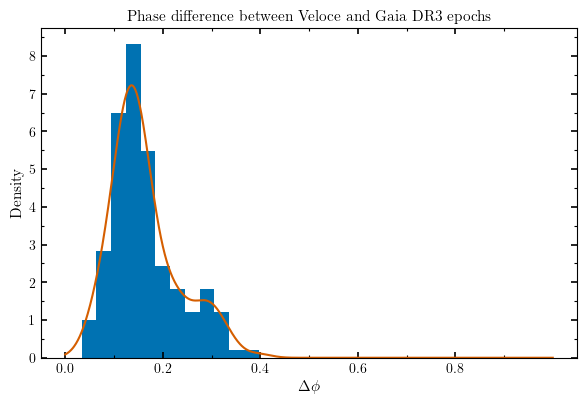

In [14]:
width = 3.46 * 2
height = width / 1.618
fig, axs = plt.subplots(figsize=(width, height))
axs.hist(
    gaia_veloce_delta["DELTA_PHASE"],
    bins=int(np.sqrt(len(gaia_veloce_delta))),
    density=True,
    color=color_safe["blue"],
    label="Data",
)
# KDE of the phase differences
kde_delta_phase = gaussian_kde(gaia_veloce_delta["DELTA_PHASE"])
x_kde = np.linspace(0, 1, 1000)
y_kde = kde_delta_phase(x_kde)
axs.plot(x_kde, y_kde, color=color_safe["dark_orange"], label="KDE")

xlim, ylim = axs.get_xlim(), axs.get_ylim()
x_ticks, x_ticks_minor = np.arange(0, 1, 0.2), np.arange(0, 1, 0.1)
y_ticks, y_ticks_minor = np.arange(0, 10, 1), np.arange(0, 10, 0.5)
vf.plot.format_xticks(axs, x_ticks, x_ticks_minor)
vf.plot.format_yticks(axs, y_ticks, y_ticks_minor)
axs.set_xlim(xlim)
axs.set_ylim(ylim)
axs.set_xlabel(r"$\Delta \phi$", fontsize=label_size)
axs.set_ylabel(r"Density", fontsize=label_size)
axs.set_title(
    "Phase difference between Veloce and Gaia DR3 epochs",
    fontsize=label_size,
)

## Analysis

First we want to divide the data in train and test set

In [15]:
saving_dir = Path(os.environ.get("RESULTS_DIR", "")).expanduser()
saving_dir.mkdir(exist_ok=True)

In [16]:
percentage_test_set = 0.15
targets = veloce_headers["NAME"].to_numpy()

# Divide in training and test sample
idx_train, idx_test = train_test_split(
    np.arange(len(targets)),
    test_size=percentage_test_set,
    random_state=40,
)
veloce_headers["SET"] = "train"
for idx, _ in veloce_headers.iterrows():
    if idx in idx_test:
        veloce_headers.loc[idx, "SET"] = "test"

# Number of training and test samples
n_train = np.sum(veloce_headers["SET"] == "train")
n_test = np.sum(veloce_headers["SET"] == "test")
print(f"Number of training samples: {n_train}")  # noqa: T201
print(f"Number of test samples: {n_test}")  # noqa: T201

Number of training samples: 186
Number of test samples: 33


### Compute sample
Define the phase grid on which to sample the pulsation

In [17]:
min_phase, max_phase = 0.0, 1.0
n_bins = 1000
phase_grid = np.linspace(min_phase, max_phase, n_bins)
phase_step = phase_grid[1] - phase_grid[0]
print(f"Min and max phase: {min_phase:.3f}, {max_phase:.3f}")  # noqa: T201
print(f"Phase step: {phase_step:.3f}")  # noqa: T201

Min and max phase: 0.000, 1.000
Phase step: 0.001


Compute sample

In [18]:
dataset = pd.DataFrame()
for _, header in veloce_headers.iterrows():
    name = header["NAME"]
    set_type = header["SET"]
    nharm = int(header["N_TERMS_FS"])
    fs_coeffs = veloce_fit[veloce_fit["NAME"] == name]["FS_COEFFS"].iloc[0]
    temp_sample = vf.model.FourierSeries(nharm=nharm).evaluate(fs_coeffs, phase_grid)

    temp = pd.DataFrame(
        {
            "NAME": name,
            "SET": set_type,
            "SAMPLE": [temp_sample],
        },
    )
    dataset = pd.concat([dataset, temp], ignore_index=True)
sample = pd.DataFrame(dataset["SAMPLE"].to_numpy().tolist(), index=dataset.index)

Separate train and test sample

In [19]:
training_set = dataset[dataset["SET"] == "train"]
training_sample = sample[dataset["SET"] == "train"]
test_set = dataset[dataset["SET"] == "test"]
test_sample = sample[dataset["SET"] == "test"]

### Preprocess the samples

I remove the mean to the sample.

In [20]:
mean_training_sample = training_sample.mean()
scaled_training_sample = training_sample - mean_training_sample
scaled_test_sample = test_sample - mean_training_sample

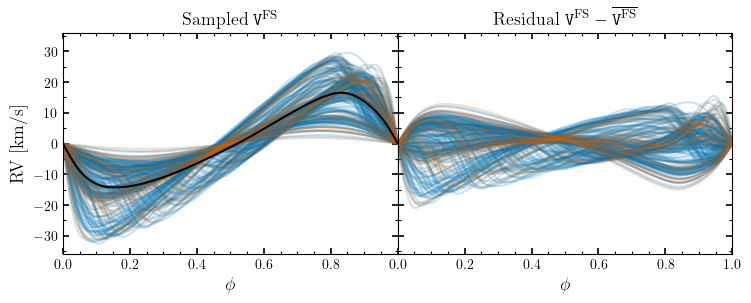

In [21]:
# Plot the scaled Fourier series
width = 3.46 * 2.2
height = width / 1.618 / 1.5
fig, axs = plt.subplots(1, 2, figsize=(width, height), sharey=True)

for _, row in training_sample.iterrows():
    axs[0].plot(phase_grid, row, color=color_safe["blue"], alpha=0.2)
for _, row in test_sample.iterrows():
    axs[0].plot(phase_grid, row, color=color_safe["dark_orange"], alpha=0.2, zorder=2)
for _, row in scaled_training_sample.iterrows():
    axs[1].plot(phase_grid, row, color=color_safe["blue"], alpha=0.2)
for _, row in scaled_test_sample.iterrows():
    axs[1].plot(phase_grid, row, color=color_safe["dark_orange"], alpha=0.2, zorder=2)

axs[0].plot(
    phase_grid,
    mean_training_sample,
    color=color_safe["black"],
    lw=1.5,
    zorder=3,
)
# y lable on the right
axs[1].yaxis.set_label_position("right")
axs[1].yaxis.tick_right()
axs[0].set_xlabel(r"$\phi$", fontsize=label_size + 2)
axs[0].set_ylabel(r"$\mathrm{RV \ [km/s]}$", fontsize=label_size + 2)
axs[0].set_title(r"Sampled $ \texttt{V}^{\rm FS}$", fontsize=label_size + 2)
axs[1].set_xlabel(r"$\phi$", fontsize=label_size + 2)
axs[1].set_title(
    r"Residual $ \texttt{V}^{\rm FS} - \overline{ \texttt{V}^{\rm FS}}$",
    fontsize=label_size + 2,
)
x_ticks = np.arange(-0.4, 1.6, 0.2)
x_ticks_minor = np.arange(-0.4, 1.6, 0.05)
vf.plot.format_xticks(axs[0], x_ticks[:-3], x_ticks_minor)
vf.plot.format_xticks(axs[1], x_ticks, x_ticks_minor)
axs[0].set_xlim(0, 1)
axs[1].set_xlim(0, 1)
y_ticks = np.arange(-40, 40, 10)
y_ticks_minor = np.arange(-45, 45, 5)
vf.plot.format_yticks(axs[0], y_ticks, y_ticks_minor)
vf.plot.format_yticks(axs[1], y_ticks, y_ticks_minor)
axs[0].set_ylim(-36, 36)
axs[1].set_ylim(-36, 36)
fig.tight_layout()
fig.subplots_adjust(wspace=0, hspace=0)
fig.savefig(saving_dir / "scaled_fourier_series.pdf")

### PCA Analysis

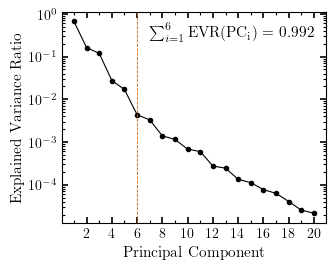

In [22]:
pca = PCA(n_components=20, svd_solver="full")
pca.fit(scaled_training_sample)

# Plot the explained variance ratio
width = 3.46
height = width * 1.618 / 2
fig, axs = plt.subplots(figsize=(width, height))
axs.plot(
    np.arange(1, pca.n_components_ + 1),
    pca.explained_variance_ratio_,
    "o-",
    color=color_safe["black"],
    markersize=3,
    lw=0.8,
)
axs.set_yscale("log")
x_ticks = np.arange(2, 22, 2)
x_ticks_minor = np.arange(1, 21, 1)
vf.plot.format_xticks(axs, x_ticks, x_ticks_minor)
yticks, y_ticks_minor = axs.get_yticks(), axs.get_yticks(minor=True)
vf.plot.format_yticks(axs, yticks, y_ticks_minor)
axs.axhline(0, color=color_safe["black"], lw=0.6, ls="--")
axs.axvline(6, color=color_safe["dark_orange"], lw=0.6, ls="--")
axs.text(
    20,
    0.65,
    (
        r"$\sum_{i=1}^6 \mathrm{EVR(PC_{i})=}$"
        f"{sum(pca.explained_variance_ratio_[:6]): .3f}"
    ),
    fontsize=11,
    color=color_safe["black"],
    weight="heavy",
    ha="right",
    va="top",
)
axs.set_xlabel("Principal Component", fontsize=11)
axs.set_ylabel("Explained Variance Ratio", fontsize=11)
fig.tight_layout()
plt.savefig(saving_dir / "pca_explained_variance_ratio_log.pdf", format="pdf")

Number of components retained: 6

In [23]:
pca = PCA(n_components=6, svd_solver="full")
pca.fit(scaled_training_sample)
print(f"PCA explained variance: {sum(pca.explained_variance_ratio_)}")  # noqa: T201

PCA explained variance: 0.9918593608909052


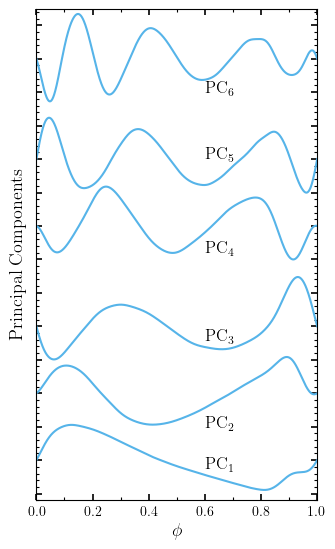

In [25]:
# Plot PCA components
width = 3.46
height = width * 1.618
fig, axs = plt.subplots(figsize=(width, height))
n_components = pca.n_components_
offset_plot_comp = [0.0, 0.1, 0.2, 0.35, 0.45, 0.6]
for i, component in enumerate(pca.components_):
    axs.plot(
        phase_grid,
        component + offset_plot_comp[i],
        label=f"Component {i + 1}",
        color=color_safe["light_blue"],
    )

    y = (component[600] + offset_plot_comp[i]) + 0.01
    if i == 1:
        y -= 0.04
    if i == 3:  # noqa: PLR2004
        y -= 0.04
    if i == 4:  # noqa: PLR2004
        y += 0.03
    if i == 5:  # noqa: PLR2004
        y -= 0.03

    x = 0.6

    axs.text(
        x,
        y,
        r"$\rm{PC_" + str(i + 1) + "}$",
        fontsize=12,
        color=color_safe["black"],
        weight="heavy",
    )

x_ticks = np.arange(-0.4, 1.6, 0.2)
x_ticks_minor = np.arange(-0.4, 1.6, 0.1)
vf.plot.format_xticks(axs, x_ticks, x_ticks_minor)
axs.set_xlim(0, 1)
y_ticks = np.arange(-0.1, 0.11 + np.max(offset_plot_comp) + 0.1, 0.05)
y_ticks_minor = np.arange(-0.08, 0.08 + np.max(offset_plot_comp) + 0.1, 0.01)
vf.plot.format_yticks(axs, y_ticks, y_ticks_minor)
axs.set_ylim(-0.06, 0.074 + np.max(offset_plot_comp))
axs.get_yaxis().set_ticklabels([])
axs.set_xlabel(r"$\phi$", fontsize=label_size + 2)
axs.set_ylabel("Principal Components", fontsize=label_size + 2)
fig.tight_layout()
plt.savefig(saving_dir / "pca_components.pdf", format="pdf")

### Fit data and samples using PCs

First, I define a model of the linear combination of the components

In [26]:
class LinearCombinationPC(vf.model.BaseModel):
    """Linear combination of the PCA components."""

    def __init__(
        self,
        pca: PCA,
        mean_training_sample: np.ndarray,
        phase_grid: np.ndarray = phase_grid,
        name: str = "lcc",
    ) -> None:
        """Initialize the model with the PCA components and the mean training sample."""
        super().__init__(name=name)
        self.pca = pca
        self.phase_grid = phase_grid
        self.components = pca.components_
        self.removed_mean = mean_training_sample

    @property
    def n_params(self) -> int:
        """Number of parameters is equal to the number of PCA components."""
        return self.components.shape[0]

    @property
    def param_names(self) -> list[str]:
        """Parameter names."""
        # pc1, pc2, ..., pcN
        return [f"pc{i}" for i in range(1, self.n_params + 1)]

    def evaluate(
        self,
        theta: list | np.ndarray,
        x: float | list | np.ndarray,
        **kwargs: object,  # noqa: ARG002
    ) -> np.ndarray:
        """Evaluate the model."""
        # Reshape theta to be a column vector
        theta = np.array(theta).reshape(-1)
        # Evaluate the linear combination
        interpolated_curve = sp.interpolate.interp1d(
            self.phase_grid,
            self.removed_mean + np.dot(self.components.T, theta),
        )
        return interpolated_curve(x)

Then I initialize it and add a constant model to account for $v_\gamma$

In [27]:
pca_puls_model = LinearCombinationPC(
    pca=pca,
    mean_training_sample=mean_training_sample.to_numpy(),
    name="pca_puls",
)

vgamma_model = vf.model.Constant(name="v_gamma")

pca_model = vgamma_model + pca_puls_model

Now that I have the correct model I start by fitting the data and separately the RV curves sampled. Any difference would be caused by the actual sampling of the observations, while any discrepancy between the optimized model and the original curve is sympton of the lost information when constraining to only the first 6 components.

219it [00:06, 36.34it/s]

Applied polynomial trend correction for alf UMi with coefficients: [ 1.03283189e-02  3.61046783e-06 -1.74268880e-08 -5.73044371e-12
  1.69962275e-14  1.17792036e-18 -7.33287257e-21  9.08533555e-25
  1.11272653e-27 -2.79142685e-31] 
 4.188 km/s


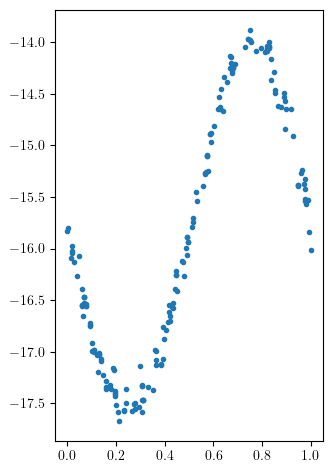

In [ ]:
fit_rv = []
for idx, header in tqdm(veloce_headers.iterrows()):
    name = header["NAME"]
    set_type = header["SET"]

    # Fit the PCs to the VELOCE data

    # 1. Get the observed data for the current target
    # NOTE: we want only the observations that were originally used to fit the
    # VELOCE Fourier series, to allow a more direct comparison between the
    # Fourier series and the PCA model
    target_data = veloce_data[(veloce_data["NAME"] == name) & (veloce_data["MASK"])]
    bjd, rv, rv_err = (
        target_data["BJD"].to_numpy().copy(),
        target_data["RV"].to_numpy().copy(),
        target_data["RV_ERR"].to_numpy().copy(),
    )
    phase = vf.model.calculate_phase(bjd, header["P"], header["E"])

    # 2. Correct for trend if polynomial is available
    target_veloce_fit = veloce_fit[veloce_fit["NAME"] == name]
    if isinstance(target_veloce_fit["POLY_COEFFS"].iloc[0], np.ndarray):
        trend_model = vf.model.PolynomialBasis(int(header["POLYDEG"]))
        trend = trend_model.evaluate(
            target_veloce_fit["POLY_COEFFS"].iloc[0],
            bjd - header["E"],
        )
        rv -= trend
        if name == "alf UMi":
            print(
                f"Applied polynomial trend correction for {name} with coefficients: "
                f"{target_veloce_fit['POLY_COEFFS'].iloc[0]}",
                f"\n{np.max(trend): .3f} km/s",
            )  # noqa: T201
            fig, ax = plt.subplots(figsize=(width, height))
            ax.plot(phase, rv, ".")

    # 3. Fit the PCA model to the observed data
    fit_result = vf.fit.fit_least_squares(
        compiled_model=pca_model,
        x=phase,
        y=rv,
        yerr=rv_err,
        theta_free_init=np.zeros(pca_model.n_params),
    )
    fit_rv.append(
        {
            "NAME": name,
            "SET": set_type,
            "LS_RESULT": fit_result,
        },
    )
fit_rv_df = pd.DataFrame(fit_rv)

#### Compare results with VELOCE

In [52]:
fit_rv_df["P2P"] = np.nan
fit_rv_df["P2P_ERR"] = np.nan
fit_rv_df["V_GAMMA"] = np.nan
fit_rv_df["V_GAMMA_ERR"] = np.nan
fit_rv_df["P2P_DELTA"] = np.nan
fit_rv_df["P2P_DELTA_RATIO"] = np.nan
fit_rv_df["V_GAMMA_DELTA"] = np.nan
fit_rv_df["V_GAMMA_DELTA_ERR"] = np.nan
fit_rv_df["V_GAMMA_DELTA_RATIO"] = np.nan
fit_rv_df["V_GAMMA_DELTA_RATIO_ERR"] = np.nan
fit_rv_df["RMSE"] = np.nan
for idx, row in fit_rv_df.iterrows():
    name = row["NAME"]
    set_type = row["SET"]
    fit_result = row["LS_RESULT"]

    phase_fit = np.linspace(0, 1, 1000)
    rv_fit = pca_model.evaluate(theta=fit_result.theta_free, x=phase_fit)
    p2p_fit = np.ptp(rv_fit)

    n_samples = 200
    p2p_values = np.zeros(n_samples)
    for i in range(n_samples):
        # Sample parameters from the covariance matrix
        # sampled_theta = rng.multivariate_normal(
        #     mean=fit_result.x,
        #     cov=fit_result.extra["covariance_matrix"],
        # )
        sampled_theta = rng.normal(
            loc=fit_result.theta_free,
            scale=fit_result.extra["theta_err"],
        )
        rv_sampled = pca_model.evaluate(theta=sampled_theta, x=phase_fit)
        p2p_values[i] = np.ptp(rv_sampled)

    p2p_err = np.std(p2p_values)
    v_gamma = fit_result.theta_free[0]
    v_gamma_err = fit_result.extra["theta_err"][0]

    # peak-to-peak
    fit_rv_df.loc[idx, "P2P"] = p2p_fit
    fit_rv_df.loc[idx, "P2P_ERR"] = p2p_err
    fit_rv_df.loc[idx, "P2P_DELTA"] = (
        p2p_fit - veloce_headers[veloce_headers["NAME"] == name]["PEAK2PEAK"].iloc[0]
    )
    fit_rv_df.loc[idx, "P2P_DELTA_RATIO"] = (
        p2p_fit - veloce_headers[veloce_headers["NAME"] == name]["PEAK2PEAK"].iloc[0]
    ) / veloce_headers[veloce_headers["NAME"] == name]["PEAK2PEAK"].iloc[0]
    # vgamma
    fit_rv_df.loc[idx, "V_GAMMA"] = v_gamma
    fit_rv_df.loc[idx, "V_GAMMA_ERR"] = v_gamma_err
    fit_rv_df.loc[idx, "V_GAMMA_DELTA"] = (
        v_gamma - veloce_fit[veloce_fit["NAME"] == name]["V_GAMMA"].iloc[0]
    )
    fit_rv_df.loc[idx, "V_GAMMA_DELTA_RATIO"] = (
        v_gamma - veloce_fit[veloce_fit["NAME"] == name]["V_GAMMA"].iloc[0]
    ) / veloce_headers[veloce_headers["NAME"] == name]["PEAK2PEAK"].iloc[0]
    fit_rv_df.loc[idx, "V_GAMMA_DELTA_RATIO_ERR"] = (
        v_gamma_err
        / veloce_headers[veloce_headers["NAME"] == name]["PEAK2PEAK"].iloc[0]
    )
    # rmse
    fit_rv_df.loc[idx, "RMSE"] = fit_result.stats.rmse

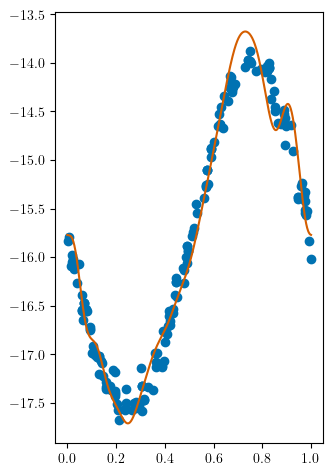

In [ ]:
# Plot fit for one of the targets
target_name = "alf UMi"
target_fit = fit_rv_df[fit_rv_df["NAME"] == target_name]["LS_RESULT"].iloc[0]
fig, ax = plt.subplots(figsize=(width, height))
ax.plot(target_fit.x, target_fit.y, "o", label="Data", color=color_safe["blue"])
ax.plot(
    phase_grid,
    pca_model.evaluate(theta=target_fit.theta_free, x=phase_grid),
    label="PCA Fit",
    color=color_safe["dark_orange"],
)

##### Determine outliers

In [ ]:
fit_rv_df["OUTLIER"] = False
fit_rv_df["OUTLIER"] = fit_rv_df["OUTLIER"].astype(bool)

# Absolute Z-score for vgamma below 3
zscore_vgamma_rv = sp.stats.zscore(fit_rv_df["V_GAMMA_DELTA"])
fit_rv_df["OUTLIER"] = fit_rv_df["OUTLIER"] | (np.abs(zscore_vgamma_rv) > 3)
# Only outlier: AV Sgr
# it is caused by the fact that we don't have many observations and the phase
# sampling is not good enough. No points between phase 0.85-0.25.

# Absolute Z-score for the delta p2p below 3
zscore_p2p_rv = sp.stats.zscore(fit_rv_df["P2P_DELTA"])
fit_rv_df["OUTLIER"] = fit_rv_df["OUTLIER"] | (np.abs(zscore_p2p_rv) > 3)
# No outliers found from the delta p2p

# Show outliers
fit_rv_df[fit_rv_df["OUTLIER"]]

,NAME,SET,LS_RESULT,P2P,P2P_ERR,V_GAMMA,V_GAMMA_ERR,P2P_DELTA,P2P_DELTA_RATIO,V_GAMMA_DELTA,V_GAMMA_DELTA_ERR,V_GAMMA_DELTA_RATIO,V_GAMMA_DELTA_RATIO_ERR,RMSE,OUTLIER
35,AV Sgr,test,"FitResult(method='least_squares', optimizer_re...",66.741806,6.954332,19.448818,1.381076,19.490058,0.412473,-4.115029,NaN,-0.087087,0.029228,0.029683,True


In [58]:
# Get only the non-outliers
fit_rv_no_outliers = fit_rv_df[~fit_rv_df["OUTLIER"]]
fit_rv_no_outliers["P"] = fit_rv_no_outliers["NAME"].apply(
    lambda name: veloce_headers[veloce_headers["NAME"] == name]["P"].iloc[0],
)

fit_rv_train_df = fit_rv_no_outliers[fit_rv_no_outliers["SET"] == "train"]
fit_rv_test_df = fit_rv_no_outliers[fit_rv_no_outliers["SET"] == "test"]

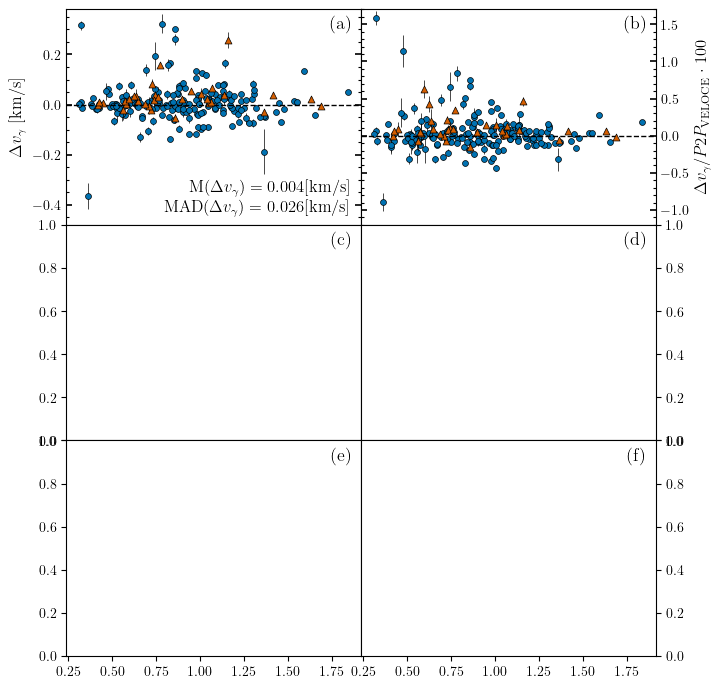

In [ ]:
width = 3.46 * 2.2
height = width * 1.618 / 2 * 3 / 2.2  # / 2
fig, axs_grid = plt.subplots(
    3, 2, figsize=(width, height), sharex=True, gridspec_kw={"hspace": 0, "wspace": 0}
)
x_ticks = np.arange(0.2, 2, 0.2)
x_ticks_minor = np.arange(0.2, 2, 0.05)
xlims = [0.22, 1.9]
for i, axs in enumerate(axs_grid.flat):
    panels = ["a", "b", "c", "d", "e", "f"]
    axs.text(
        0.97,
        0.97,
        f"({panels[i]})",
        transform=axs.transAxes,
        fontsize=label_size + 2,
        ha="right",
        va="top",
    )
    if i % 2 == 1:
        axs.yaxis.set_label_position("right")
        axs.yaxis.tick_right()
    if i == 0:
        train_delta_vgamma = fit_rv_train_df["V_GAMMA_DELTA"]
        train_delta_vgamma_err = fit_rv_train_df["V_GAMMA_ERR"]
        test_delta_vgamma = fit_rv_test_df["V_GAMMA_DELTA"]
        test_delta_vgamma_err = fit_rv_test_df["V_GAMMA_ERR"]

        # Training set
        axs.errorbar(
            np.log10(fit_rv_train_df["P"]),
            train_delta_vgamma,
            yerr=train_delta_vgamma_err,
            fmt=",",
            lw=0.5,
            color=color_safe["black"],
            zorder=1,
        )
        sc = axs.scatter(
            np.log10(fit_rv_train_df["P"]),
            train_delta_vgamma,
            c=color_safe["blue"],
            s=18,
            alpha=1,
            marker="o",
            edgecolors="k",
            linewidths=0.5,
            zorder=2,
        )
        # Test set
        axs.errorbar(
            np.log10(fit_rv_test_df["P"]),
            test_delta_vgamma,
            yerr=test_delta_vgamma_err,
            fmt=",",
            lw=0.5,
            color=color_safe["black"],
            zorder=3,
        )
        sc = axs.scatter(
            np.log10(fit_rv_test_df["P"]),
            test_delta_vgamma,
            c=color_safe["dark_orange"],
            s=25,
            alpha=1,
            marker="^",
            edgecolors="k",
            linewidths=0.5,
            zorder=4,
        )
        y_ticks = np.arange(-0.6, 0.6, 0.2)
        y_ticks_minor = np.arange(-0.8, 0.6, 0.05)
        vf.plot.format_yticks(axs, y_ticks, y_ticks_minor)
        axs.set_ylim(-0.48, 0.38)
        text = (
            r"$\mathrm{M}(\Delta v_\gamma) = "
            f"{np.median(fit_rv_df['V_GAMMA_DELTA']):.3f}"
            "$"
        )
        text += "[km/s]\n"
        text += (
            r"$\mathrm{MAD}(\Delta v_\gamma) = "
            f"{sp.stats.median_abs_deviation(fit_rv_df['V_GAMMA_DELTA']):.3f}"
            "$"
        )
        text += "[km/s]"
        axs.text(
            1.85,
            -0.45,
            s=text,
            fontsize=12,
            verticalalignment="bottom",
            horizontalalignment="right",
        )
        axs.axhline(0, color=color_safe["black"], lw=1, ls="--")

        axs.set_ylabel(r"$\Delta v_\gamma \ \mathrm{[km/s]}$", fontsize=12)

    elif i == 1:
        train_delta_vgamma_ratio = fit_rv_train_df["V_GAMMA_DELTA_RATIO"]
        train_delta_vgamma_ratio_err = fit_rv_train_df["V_GAMMA_DELTA_RATIO_ERR"]
        test_delta_vgamma_ratio = fit_rv_test_df["V_GAMMA_DELTA_RATIO"]
        test_delta_vgamma_ratio_err = fit_rv_test_df["V_GAMMA_DELTA_RATIO_ERR"]
        # Training set
        axs.errorbar(
            np.log10(fit_rv_train_df["P"]),
            train_delta_vgamma_ratio * 100,
            yerr=train_delta_vgamma_ratio_err * 100,
            fmt=",",
            lw=0.5,
            color=color_safe["black"],
            zorder=1,
        )
        sc = axs.scatter(
            np.log10(fit_rv_train_df["P"]),
            train_delta_vgamma_ratio * 100,
            c=color_safe["blue"],
            s=18,
            alpha=1,
            marker="o",
            edgecolors="k",
            linewidths=0.5,
            zorder=2,
        )
        # Test set
        axs.errorbar(
            np.log10(fit_rv_test_df["P"]),
            test_delta_vgamma_ratio * 100,
            yerr=test_delta_vgamma_ratio_err * 100,
            fmt=",",
            lw=0.5,
            color=color_safe["black"],
            zorder=3,
        )
        sc = axs.scatter(
            np.log10(fit_rv_test_df["P"]),
            test_delta_vgamma_ratio * 100,
            c=color_safe["dark_orange"],
            s=25,
            alpha=1,
            marker="^",
            edgecolors="k",
            linewidths=0.5,
            zorder=4,
        )

        y_ticks = np.arange(-1.0, 2, 0.5)
        y_ticks_minor = np.arange(-1.3, 3, 0.1)
        vf.plot.format_yticks(axs, y_ticks, y_ticks_minor)
        axs.set_ylim(-1.2, 1.7)
        axs.axhline(0, color=color_safe["black"], lw=1, ls="--")
        axs.set_ylabel(
            r"$\Delta v_\gamma / P2P_{\mathrm{VELOCE}} \cdot 100$", fontsize=12
        )

    elif i == 2:
        axs.errorbar(
            np.log10(fit_rv_train_df["P"]),
            fit_rv_train_df["P2P_DELTA"],
            yerr=fit_rv_train_df["P2P_DELTA_ERR"],
            fmt=",",
            lw=0.5,
            color=color_safe["black"],
            zorder=1,
        )
        axs.scatter(
            np.log10(fit_rv_train_df["P"]),
            fit_rv_train_df["P2P_DELTA"],
            c=color_safe["blue"],
            s=18,
            alpha=1,
            marker="o",
            edgecolors="k",
            linewidths=0.5,
            zorder=2,
        )
        axs.errorbar(
            np.log10(fit_rv_test_df["P"]),
            fit_rv_test_df["P2P_DELTA"],
            yerr=fit_rv_test_df["P2P_DELTA_ERR"],
            fmt=",",
            lw=0.5,
            color=color_safe["black"],
            zorder=1,
        )
        axs.scatter(
            np.log10(fit_rv_test_df["P"]),
            fit_rv_test_df["P2P_DELTA"],
            c=color_safe["dark_orange"],
            s=25,
            alpha=1,
            marker="^",
            edgecolors="k",
            linewidths=0.5,
            zorder=2,
        )

        y_ticks = np.arange(-8, 6, 2)
        y_ticks_minor = np.arange(-8, 6, 0.5)
        vf.plot.format_yticks(axs, y_ticks, y_ticks_minor)
        axs.set_ylim(-4.75, 4.75)

        text = (
            r"$\mathrm{M}(\Delta  P2P) = "
            f"{np.median(fit_rv_no_outliers['P2P_DELTA']):.3f}"
            "$"
        )
        text += "[km/s]\n"
        text += (
            r"$\mathrm{MAD}(\Delta  P2P) = "
            f"{sp.stats.median_abs_deviation(fit_rv_no_outliers['P2P_DELTA']):.3f}"
            "$"
        )
        text += "[km/s]"
        print(
            f"MAD P2P: {sp.stats.median_abs_deviation(fit_rv_no_outliers['P2P_DELTA'])}"
        )
        axs.text(
            0.3,
            4.25,
            s=text,
            fontsize=12,
            verticalalignment="top",
            horizontalalignment="left",
        )
        axs.axhline(0, color=color_safe["black"], lw=1, ls="--")
        axs.set_ylabel(r"$\Delta  P2P \ \mathrm{[km/s]}$", fontsize=12)

    elif i == 3:
        axs.errorbar(
            np.log10(fit_rv_train_df["P"]),
            fit_rv_train_df["P2P_DELTA_ratio"] / fit_rv_train_df["P2P"] * 100,
            yerr=fit_rv_train_df["P2P_DELTA_ERR"] / fit_rv_train_df["P2P"] * 100,
            fmt=",",
            lw=0.5,
            color=color_safe["black"],
            zorder=1,
        )
        axs.scatter(
            dataset_fit_train["logp"],
            dataset_fit_train["fit_rv_p2p_diff_ratio"] * 100,
            c=color_safe["blue"],
            s=18,
            alpha=1,
            marker="o",
            edgecolors="k",
            linewidths=0.5,
            zorder=2,
        )
        axs.errorbar(
            dataset_fit_test["logp"],
            dataset_fit_test["fit_rv_p2p_diff_ratio"] * 100,
            yerr=dataset_fit_test["fit_rv_p2p_diff_ratio_err"] * 100,
            fmt=",",
            lw=0.5,
            color=color_safe["black"],
            zorder=1,
        )
        axs.scatter(
            dataset_fit_test["logp"],
            dataset_fit_test["fit_rv_p2p_diff_ratio"] * 100,
            c=color_safe["dark_orange"],
            s=25,
            alpha=1,
            marker="^",
            edgecolors="k",
            linewidths=0.5,
            zorder=2,
        )
        # Only annotate targets in the outliers list
        for i, row in dataset_fit_no_outliers.iterrows():
            if row["target"] in highlight_outliers.keys():
                if row["target"] in highlight_outliers.keys():
                    yyy = (
                        0.4
                        if row["target"] not in ["ASAS J064540+0330.4", "alf UMi"]
                        else -0.6
                    )
                    text_note = (
                        row["target"] if row["target"] != "alf UMi" else r"$\alpha$UMi"
                    )
                    print(row["target"])
                    axs.annotate(
                        text_note,
                        (row["logp"], row["fit_rv_p2p_diff_ratio"] * 100),
                        xycoords="data",
                        textcoords="offset fontsize",
                        xytext=(0.4, yyy),
                        ha="left",
                        fontsize=9,
                        color="black",  # Optional: highlight outliers
                        zorder=10,
                    )

        y_ticks = 100 * np.arange(-0.15, 0.2, 0.05)
        y_ticks_minor = 100 * np.arange(-0.2, 0.2, 0.01)
        format_yticks(axs, y_ticks, y_ticks_minor)
        axs.set_ylim(-0.11 * 100, 0.16 * 100)
        axs.axhline(0, color=color_safe["black"], lw=1, ls="--")

        axs.set_ylabel(
            r"$\Delta  P2P / P2P_{\mathrm{VELOCE}} \cdot 100$", fontsize=font_size
        )

In [35]:
np.asarray(np.zeros(pca_model.n_params), dtype=float).ravel().shape

(7,)

In [44]:
np.dot(pca_puls_model.components.T, np.zeros(pca_puls_model.n_params)).shape

(1000,)

In [42]:
pca_puls_model.components.shape

(6, 1000)

In [36]:
pca_model_ = pca_model.evaluate(
    theta=np.zeros(pca_model.n_params),
    x=phase_grid,
)

In [37]:
pca_model_.shape

(1000, 1000)

In [38]:
vgamma_model.evaluate(theta=0, x=phase_grid).shape

(1000,)

In [39]:
pca_puls_model.evaluate(theta=np.zeros(pca_puls_model.n_params), x=phase_grid).shape

(1000, 1000)

In [ ]:
veloce_headers[
    ~(veloce_headers["GAIA_DR3_SOURCE_ID"].astype(int).isin(df_gaiadr3["source_id"]))
]

,NAME,GAIA_DR3_SOURCE_ID,RA,DEC,USED_SOURCES,OBSERVED_WITH_CORALIE07,OBSERVED_WITH_CORALIE14,OBSERVED_WITH_HERMES,N_RV,N_RV_CORALIE07,...,KP_VL_ECCENTRICITY,KP_VL_ECCENTRICITY_ERR,KP_VL_ARGPERI,KP_VL_ARGPERI_ERR,KP_VL_T0,KP_VL_T0_ERR,KP_VL_A_SINI,KP_VL_A_SINI_ERR,KP_VL_F_MASS,KP_VL_F_MASS_ERR
151,BB Gem,3355398399202605696,06 34 35.2939,+13 04 44.708,"Coralie07,Coralie14,Hermes",True,True,True,13,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
152,BB Sgr,4085919765884068736,18 50 59.8729,-20 17 42.829,"Coralie07,Coralie14,Hermes",True,True,True,101,56,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
186,FM Aql,4312361436842603520,19 09 15.9900,+10 33 08.961,Hermes,False,False,True,15,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
258,RT Aur,3435571660360952704,06 28 34.0881,+30 29 34.929,"Coralie14,Hermes",False,True,True,37,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
287,SZ Aql,4267549637851481344,19 04 39.4158,+01 18 22.158,"Coralie14,Hermes",False,True,True,92,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
292,T Mon,3324535073449061504,06 25 12.9996,+07 05 08.558,"Coralie07,Coralie14,Hermes",True,True,True,181,32,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
293,TT Aql,4267397694768545920,19 08 13.7497,+01 17 55.147,"Coralie14,Hermes",False,True,True,80,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
300,TZ Mon,3112475495616980992,06 58 00.9347,-00 22 33.463,"Coralie14,Hermes",False,True,True,43,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
303,U Sgr,4092905375639902464,18 31 53.3323,-19 07 30.261,"Coralie07,Coralie14,Hermes",True,True,True,34,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
415,alf UMi,-1,02 31 49.0945,+89 15 50.792,Hermes,False,False,True,186,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
veloce_headers[veloce_headers["NAME"] == "BB Gem"]["GAIA_DR3_SOURCE_ID"]

151    3355398399202605696
Name: GAIA_DR3_SOURCE_ID, dtype: str

In [12]:
veloce_headers[veloce_headers["NAME"] == "BB Gem"]["GAIA_DR3_SOURCE_ID"].astype(int)

151    3355398399202605696
Name: GAIA_DR3_SOURCE_ID, dtype: int64

In [11]:
for col in veloce_headers.columns:
    print(f"{col}: {veloce_headers[col].dtype}")

NAME: str
GAIA_DR3_SOURCE_ID: str
RA: str
DEC: str
USED_SOURCES: str
OBSERVED_WITH_CORALIE07: bool
OBSERVED_WITH_CORALIE14: bool
OBSERVED_WITH_HERMES: bool
N_RV: int64
N_RV_CORALIE07: int64
N_RV_CORALIE14: int64
N_RV_HERMES: int64
BJD_MIN: float64
BJD_MAX: float64
BASELINE: float64
BOOL_CLASSICAL_CEPHEID: object
BOOL_DOUBLE_BUMP: bool
BOOL_SB1: object
BOOL_FIT_AVAILABLE: bool
BOOL_INTERPOLATED: bool
BOOL_TEMPLATE_FITTING_ANALYSIS: bool
BOOL_KEPLERIAN_VL: bool
BOOL_CIRCULAR_VL: bool
P: float64
P_ERR_SYST: float64
P_ERR_STAT: float64
P_ERR: float64
E: float64
E_ERR_SYST: float64
E_ERR_STAT: float64
E_ERR: float64
N_DOF: float64
CHISQ: float64
NORMALIZED_CHISQ: float64
STDDEV: float64
STDMER: float64
N_TERMS_FS: float64
BOOL_POLYNOMIAL: object
BOOL_KEPLERIAN: object
VGAMMA_0: float64
VGAMMA_0_ERR: float64
DELTA_RADIUS_OVER_P: float64
INTERCEPT_PHASE: float64
PEAK2PEAK: float64
MIN_RV: float64
MIN_RV_PHASE: float64
MAX_RV: float64
MAX_RV_PHASE: float64
R21: float64
R31: float64
R41: float6